# March Machine Learning Mania 2026 Starter

## ADKとは
Google ga提供するAIえージョンと構築のためのオープンソースフレームワークです。ツールを定義し、それらをLLM搭載エージェントSequentialAgentに接続し、ParallelAgentやLoopAgentなどのパターンを使用してマルチエージェントワークフローをオーケストレーションします。

1. データ読み込み
2. Eloレーティング計算
3. 勝敗予測モデル作成
4. 提出ファイル生成

In [56]:
# ┌─────────────┐     ┌──────────────────┐     ┌──────────────┐     ┌────────────────┐
# │ Data Loader │───▶ │ Feature Engineer │───▶ │ Model Trainer│───▶ │ Submission Gen │
# │    Agent    │     │      Agent       │     │    Agent     │     │     Agent      │
# └─────────────┘     └──────────────────┘     └──────────────┘     └────────────────┘
#   load_data()          compute_elo()           train_model()     generate_submission()

In [57]:
import os, json, asyncio, warnings
from dotenv import load_dotenv
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

load_dotenv()

warnings.filterwarnings('ignore')

# ── Configure Gemini API Key ──
try:
    from kaggle_secrets import UserSecretsClient
    os.environ['GOOGLE_API_KEY'] = UserSecretsClient().get_secret('GOOGLE_API_KEY')
    print('✅ API key loaded from Kaggle Secrets')
except Exception:
    pass

# Or set directly:
os.environ['GOOGLE_API_KEY'] = os.getenv("GOOGLE_API_KEY")

assert 'GOOGLE_API_KEY' in os.environ, '❌ Set GOOGLE_API_KEY as a Kaggle Secret!'

# ── ADK Imports ──
from google.adk.agents import LlmAgent
from google.adk.agents.sequential_agent import SequentialAgent
from google.adk.sessions import InMemorySessionService
from google.adk.runners import Runner
from google.genai.types import Content, Part

print('✅ All imports successful — ADK ready!')

✅ All imports successful — ADK ready!


In [58]:
# ── Configuration ──
DATA_DIR = './data'
GEMINI_MODEL = 'gemini-2.5-flash'
CURRENT_SEASON = 2026

# Elo hyperparameters — tune these!
ELO_K = 20       # K-factor: how much each game shifts ratings
ELO_INIT = 1500  # Starting Elo for all teams
ELO_HCA = 100    # Home court advantage in Elo points

# Global state (populated by tools, shared across agents via output_key)
DATA = {}   # loaded dataframes
ELO = {}    # (season, team_id) -> elo rating
MODEL = None  # trained sklearn model

## ツールの定義

このセクションでは**LLMが使えるツールとしてPython関数を定義**している。<br>
LLMはこれらを呼び出して処理を実行している。

### Tool1: コンペティションデータのロード
すべてのコンペティションCSV ファイルを読み込み、概要を返します。<br>
男子および女子チームの情報、レギュラーシーズンの結果、トーナメントの結果、トーナメントのシード、およびサンプル提出ファイルを読み込みます<br>
    
return: ステータス、データセットのサイズ、およびメッセージを含む概要。(dict)

In [59]:
def load_competition_data() -> dict:
    DATA['m_teams'] = pd.read_csv(f'{DATA_DIR}/MTeams.csv')
    DATA['w_teams'] = pd.read_csv(f'{DATA_DIR}/WTeams.csv')
    DATA['m_regular'] = pd.read_csv(f'{DATA_DIR}/MRegularSeasonCompactResults.csv')
    DATA['w_regular'] = pd.read_csv(f'{DATA_DIR}/WRegularSeasonCompactResults.csv')
    DATA['m_tourney'] = pd.read_csv(f'{DATA_DIR}/MNCAATourneyCompactResults.csv')
    DATA['w_tourney'] = pd.read_csv(f'{DATA_DIR}/WNCAATourneyCompactResults.csv')
    DATA['m_seeds'] = pd.read_csv(f'{DATA_DIR}/MNCAATourneySeeds.csv')
    DATA['w_seeds'] = pd.read_csv(f'{DATA_DIR}/WNCAATourneySeeds.csv')
    DATA['sample_sub'] = pd.read_csv(f'{DATA_DIR}/SampleSubmissionStage1.csv')

    return {
        'status': 'success',
        'seasons': f"{DATA['m_regular']['Season'].min()}-{DATA['m_regular']['Season'].max()}",
        'mens_teams': len(DATA['m_teams']),
        'womens_teams': len(DATA['w_teams']),
        'regular_season_games': len(DATA['m_regular']) + len(DATA['w_regular']),
        'tourney_games': len(DATA['m_tourney']) + len(DATA['w_tourney']),
        'submission_rows': len(DATA['sample_sub']),
        'message': 'All data loaded successfully. Ready for feature engineering.'
    }

print("✅ Tool 1 defined: load_competition_data")

✅ Tool 1 defined: load_competition_data


### Tool 2: Eloレーティング(特徴量)
Eloレーティングとはチームの強さを数値化する方法の一つです。<br>
勝つとレートが上昇し、負けるとレートが下降します。また、実力差の大きい相手との勝敗ほどレートの変動も大きくなります。<br>
全シーズンの男子チームと女子チームのEloレーティングを計算します。<br>
Kファクター、ホームコートアドバンテージ、シーズン間の平均への回帰を考慮した標準的なEloシステムを使用します。<br>

return：最高評価チームと計算された合計レーティングの概要。(dict)


In [60]:
def compute_elo_ratings() -> dict:
    def _run_elo(regular_df, tourney_df):
        elo = {}
        season_elos = {}
        all_games = pd.concat([regular_df, tourney_df]).sort_values(['Season', 'DayNum'])
        prev_season = None

        for _, row in all_games.iterrows():
            season = row['Season']
            if season != prev_season and prev_season is not None:
                for tid, r in elo.items():
                    season_elos[(prev_season, tid)] = r
                elo = {tid: 0.75 * r + 0.25 * ELO_INIT for tid, r in elo.items()}
            prev_season = season

            w_id, l_id = row['WTeamID'], row['LTeamID']
            w_elo = elo.get(w_id, ELO_INIT)
            l_elo = elo.get(l_id, ELO_INIT)

            # Home court adjustment
            w_loc = row.get('WLoc', 'N')
            w_adj = w_elo + (ELO_HCA if w_loc == 'H' else (-ELO_HCA if w_loc == 'A' else 0))

            # Expected win probability & update
            exp_w = 1.0 / (1.0 + 10 ** ((l_elo - w_adj) / 400.0))
            elo[w_id] = w_elo + ELO_K * (1.0 - exp_w)
            elo[l_id] = l_elo + ELO_K * (0.0 - (1.0 - exp_w))

        if prev_season:
            for tid, r in elo.items():
                season_elos[(prev_season, tid)] = r
        return season_elos

    m_elos = _run_elo(DATA['m_regular'], DATA['m_tourney'])
    w_elos = _run_elo(DATA['w_regular'], DATA['w_tourney'])
    ELO.update(m_elos)
    ELO.update(w_elos)

    # Top teams for display
    m_names = dict(zip(DATA['m_teams']['TeamID'], DATA['m_teams']['TeamName']))
    w_names = dict(zip(DATA['w_teams']['TeamID'], DATA['w_teams']['TeamName']))
    latest_m = max(s for s, _ in m_elos.keys())
    latest_w = max(s for s, _ in w_elos.keys())
    top_m = sorted([(tid, r) for (s, tid), r in m_elos.items() if s == latest_m], key=lambda x: -x[1])[:5]
    top_w = sorted([(tid, r) for (s, tid), r in w_elos.items() if s == latest_w], key=lambda x: -x[1])[:5]

    return {
        'status': 'success',
        'total_ratings': len(ELO),
        'top_mens': [f"{m_names.get(t, t)}: {r:.0f}" for t, r in top_m],
        'top_womens': [f"{w_names.get(t, t)}: {r:.0f}" for t, r in top_w],
        'message': f'Elo computed through {latest_m} (men) and {latest_w} (women).'
    }

print("✅ Tool 2 defined: compute_elo_ratings")

✅ Tool 2 defined: compute_elo_ratings


### Tool 3: 予測モデル作成
Eloレーティングの差とシードの差に基づいてロジスティック回帰を学習します。<br>
過去のトーナメントの対戦データ（2003年以降）から学習データを作成します。<br>
特徴量：[elo_diff, seed_diff]（diff = Team1 - Team2、Team1 = 下位のTeamID）。5分割交差検証で評価します。<br>

return：学習データのサイズ、Brierスコア、モデル情報を含む要約。(dict)


In [61]:
def _parse_seed(seed_str):
    """Extract numeric seed from string like 'W01', 'X16a' → 1, 16."""
    return int(seed_str[1:3])


def train_prediction_model() -> dict:
    global MODEL

    # Seed lookup
    seed_map = {}
    for df in [DATA['m_seeds'], DATA['w_seeds']]:
        for _, row in df.iterrows():
            seed_map[(row['Season'], row['TeamID'])] = _parse_seed(row['Seed'])

    # Build training set from tournament games
    X, y = [], []
    for t_df in [DATA['m_tourney'], DATA['w_tourney']]:
        for _, row in t_df.iterrows():
            season = row['Season']
            if season < 2003:
                continue

            w_id, l_id = row['WTeamID'], row['LTeamID']
            # Use PREVIOUS season Elo as pre-tournament rating
            w_elo = ELO.get((season - 1, w_id), ELO_INIT)
            l_elo = ELO.get((season - 1, l_id), ELO_INIT)
            w_seed = seed_map.get((season, w_id), 8)
            l_seed = seed_map.get((season, l_id), 8)

            # Convention: team1 = lower ID
            if w_id < l_id:
                X.append([w_elo - l_elo, l_seed - w_seed])
                y.append(1)
            else:
                X.append([l_elo - w_elo, w_seed - l_seed])
                y.append(0)

    X, y = np.array(X), np.array(y)

    # Train
    MODEL = LogisticRegression(C=1.0, solver='lbfgs')
    MODEL.fit(X, y)

    # Cross-val Brier score (lower = better)
    cv_probs = cross_val_score(
        LogisticRegression(C=1.0, solver='lbfgs'), X, y,
        scoring='neg_brier_score', cv=5
    )
    brier = -cv_probs.mean()

    return {
        'status': 'success',
        'training_games': len(y),
        'win_rate_label1': f"{y.mean():.3f}",
        'cv_brier_score': f"{brier:.4f}",
        'coefficients': {
            'elo_diff': f"{MODEL.coef_[0][0]:.6f}",
            'seed_diff': f"{MODEL.coef_[0][1]:.6f}",
            'intercept': f"{MODEL.intercept_[0]:.6f}"
        },
        'message': f'Model trained on {len(y)} games. CV Brier: {brier:.4f}'
    }

print("✅ Tool 3 defined: train_prediction_model")

✅ Tool 3 defined: train_prediction_model


### Tool 4: Submissionファイル生成
考えられるすべての対戦について予測を生成し、submission.csv に保存します。<br>
サンプル提出の各行について、2 つのチーム ID を抽出し、特徴 (Elo diff、seed diff) を計算し、P(Team1 が勝つ) を予測します。チームに Elo レーティングがない場合は、0.5 にフォールバックします。<br>

return: 予測数と出力パスを含む概要(dict)

In [62]:
def generate_submission() -> dict:
    sub = DATA['sample_sub'].copy()

    # Seed lookup for ALL seasons (not just current)
    seed_map = {}
    for df in [DATA['m_seeds'], DATA['w_seeds']]:
        for _, row in df.iterrows():
            seed_map[(row['Season'], row['TeamID'])] = _parse_seed(row['Seed'])

    preds = []
    for _, row in sub.iterrows():
        parts = row['ID'].split('_')
        season = int(parts[0])
        t1, t2 = int(parts[1]), int(parts[2])  # t1 < t2 by construction

        # Use prior season's Elo for each row's own season
        latest_season = season - 1

        e1 = ELO.get((latest_season, t1), ELO_INIT)
        e2 = ELO.get((latest_season, t2), ELO_INIT)
        s1 = seed_map.get((season, t1), 8)
        s2 = seed_map.get((season, t2), 8)

        features = np.array([[e1 - e2, s2 - s1]])
        prob = MODEL.predict_proba(features)[0][1]
        # Clip to avoid extreme probabilities
        prob = np.clip(prob, 0.01, 0.99)
        preds.append(prob)

    sub['Pred'] = preds
    output_path = './working/submission.csv'
    sub.to_csv(output_path, index=False)

    return {
        'status': 'success',
        'num_predictions': len(preds),
        'mean_pred': f"{np.mean(preds):.4f}",
        'std_pred': f"{np.std(preds):.4f}",
        'output_path': output_path,
        'message': f'Submission saved to {output_path} with {len(preds)} predictions.'
    }

print("✅ Tool 4 defined: generate_submission")

✅ Tool 4 defined: generate_submission


## ADKエージェントの定義

LlmAgentの各エージェントは以下を持つ
- **instruction** : このエージェントの役割をLLMに伝える
- **tools** : 呼び出すことができるPython関数
- **output_key** : エージェントの最終応答を共有セッション状態に保存し、次のエージェントが{key}テンプレートを使用してそれを読み取ることができるようにする。

次に、それらをSequentialAgentにまとめて、データパイプラインのように順番に実行します。

In [63]:
# ── Agent 1: データローダー ──
# instruction =
# あなたは、マーチマッドネス予測パイプラインのデータ読み込みスペシャリストです。
# あなたの仕事は以下のとおりです。
# 1. `load_competition_data`ツールを呼び出して、すべての競技CSVファイルをロードします。
# 2. ロードされた内容の簡単な要約を報告します（チーム数、ゲーム数、シーズン数）。
# 3. 次のステージの準備ができていることを確認します。
# 簡潔にしてください - 重要な数字と確認だけで十分です。
data_loader_agent = LlmAgent(
    name="DataLoaderAgent",
    model=GEMINI_MODEL,
    instruction="""You are a data loading specialist for the March Madness prediction pipeline.

Your job:
1. Call the `load_competition_data` tool to load all competition CSV files.
2. Report a brief summary of what was loaded (number of teams, games, seasons).
3. Confirm the data is ready for the next stage.

Be concise — just the key numbers and a confirmation.""",
    description="Loads and summarizes the competition dataset.",
    tools=[load_competition_data],
    output_key="data_summary"
)


# ── Agent 2: 特徴量エンジニアリング ──
# instruction =
# あなたは、マーチマッドネス予測パイプラインの特徴量エンジニアリングスペシャリストです。
# あなたの仕事は以下のとおりです。
# 1. `compute_elo_ratings`を呼び出して、すべてのチームのEloレーティングを計算します。
# 2. 評価の高い男子チームと女子チームを報告します。
# 3. 特徴量がモデル訓練の準備ができていることを確認します。
# 簡潔にしてください - トップチームの名前とレーティング、そして準備完了の確認だけで十分です。
feature_engineer_agent = LlmAgent(
    name="FeatureEngineerAgent",
    model=GEMINI_MODEL,
    instruction="""You are a feature engineering specialist.

Previous stage summary: {data_summary}

Your job:
1. Call `compute_elo_ratings` to calculate Elo ratings for all teams.
2. Report the top-rated men's and women's teams.
3. Confirm features are ready for model training.

Be concise.""",
    description="Computes Elo ratings as features for prediction.",
    tools=[compute_elo_ratings],
    output_key="feature_summary"
)

# ── Agent 3: モデルトレーナー ──
# instruction =
# あなたは、マーチマッドネス予測パイプラインのモデル訓練スペシャリストです。
# あなたの仕事は以下のとおりです。
# 1. `train_prediction_model`を呼び出して、ロジスティック回帰モデルを訓練します。
# 2. クロスバリデーションのBrierスコアとモデル係数を報告します。
# 3. どの特徴量（Elo差またはシード差）がモデルにとってより重要かを簡単に解釈します。
# 簡潔にしてください。 - Brierスコア、係数、そして特徴量の重要性の解釈だけで十分です。
model_trainer_agent = LlmAgent(
    name="ModelTrainerAgent",
    model=GEMINI_MODEL,
    instruction="""You are a model training specialist.

Previous stage summary: {feature_summary}

Your job:u
1. Call `train_prediction_model` to train a logistic regression model.
2. Report the cross-validation Brier score and model coefficients.
3. Briefly interpret which feature (Elo or seed) matters more.

Be concise.""",
    description="Trains and evaluates the prediction model.",
    tools=[train_prediction_model],
    output_key="model_summary"
)

# ── Agent 4: Submission生成器  ──
# instruction =
# あなたは、マーチマッドネス予測パイプラインのSubmission生成スペシャリストです。
# あなたの仕事は以下のとおりです。  
# 1. `generate_submission`を呼び出して、すべての対戦の予測を作成します。
# 2. Submissionファイルが保存された場所と基本的な予測統計を報告します。
# 3. モデル改善のための具体的なアイデアを2-3提案します。
# 簡潔にしてください。 - 結果の要約と改善アイデアだけで十分です。
submission_agent = LlmAgent(
    name="SubmissionAgent",
    model=GEMINI_MODEL,
    instruction="""You are a submission generation specialist.

Previous stage summary: {model_summary}

Your job:
1. Call `generate_submission` to create predictions for all matchups.
2. Report where the submission file was saved and basic prediction stats.
3. Suggest 2-3 concrete ideas for improving the model.

Be concise.""",
    description="Generates the final submission CSV.",
    tools=[generate_submission],
    output_key="submission_summary"
)

print("✅ All 4 agents defined")

✅ All 4 agents defined


## シーケンシャルパイプラインの構築と実行

ADKはSequentialAgentサブエージェントを順番に実行します。各エージェントを介して出力をセッション状態に書き込みoutput_key、次のエージェントは{key}命令内のプレースホルダーを介してそれを読み取ります。

これはADKにおけるデータパイプラインに相当するもので、各ステップでLLM(論理レベル管理)による実行を伴う決定論的な順序付けが実現されています。

In [64]:
# ── Compose the pipeline ──
pipeline = SequentialAgent(
    name="MarchMadnessPipeline",
    sub_agents=[
        data_loader_agent,
        feature_engineer_agent,
        model_trainer_agent,
        submission_agent,
    ],
    description="End-to-end March Madness prediction pipeline."
)

print("✅ Pipeline assembled: DataLoader → FeatureEngineer → ModelTrainer → Submission")

✅ Pipeline assembled: DataLoader → FeatureEngineer → ModelTrainer → Submission


In [ ]:
# ── Run the pipeline ──

APP_NAME = "march_madness_2026"
USER_ID = "kaggle_user"
SESSION_ID = "pipeline_run_1"

async def run_pipeline():
    """Execute the full agent pipeline and print each agent's output."""
    session_service = InMemorySessionService()
    runner = Runner(
        agent=pipeline,
        app_name=APP_NAME,
        session_service=session_service,
    )

    # Create session
    session = await session_service.create_session(
        app_name=APP_NAME,
        user_id=USER_ID,
        session_id=SESSION_ID,
    )

    # Kick off the pipeline with a user message
    user_message = Content(
        role="user",
        parts=[Part(text="Run the full March Madness prediction pipeline. "
                         "Load data, compute features, train the model, "
                         "and generate the submission file.")]
    )

    print("🚀 Starting pipeline...\n")
    print("=" * 60)

    async for event in runner.run_async(
        user_id=USER_ID,
        session_id=session.id,
        new_message=user_message,
    ):
        # Print each agent's final response
        if event.is_final_response() and event.content and event.content.parts:
            author = event.author or "Pipeline"
            text = event.content.parts[0].text if event.content.parts[0].text else ""
            if text.strip():
                print(f"\n🤖 [{author}]")
                print("-" * 40)
                print(text.strip())
                print("=" * 60)

    print("\n✅ Pipeline complete!")
    return session

# In Kaggle notebooks, an event loop is already running
session = await run_pipeline()

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


🚀 Starting pipeline...



_ResourceExhaustedError: 
On how to mitigate this issue, please refer to:

https://google.github.io/adk-docs/agents/models/#error-code-429-resource_exhausted


429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 45.252795623s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier

## 提出内容の確認

In [ ]:
print(DATA['sample_sub'].shape)
print(DATA['sample_sub'].head())
print(DATA['sample_sub']['ID'].str[:4].unique())

(519144, 2)
               ID  Pred
0  2022_1101_1102   0.5
1  2022_1101_1103   0.5
2  2022_1101_1104   0.5
3  2022_1101_1105   0.5
4  2022_1101_1106   0.5
['2022' '2023' '2024' '2025']


In [ ]:

# ── Check the output ──
sub = pd.read_csv('./working/submission.csv')
print(f"Submission shape: {sub.shape}")
print(f"Prediction range: [{sub['Pred'].min():.4f}, {sub['Pred'].max():.4f}]")
print(f"Mean prediction:  {sub['Pred'].mean():.4f}")
print(f"Std prediction:   {sub['Pred'].std():.4f}")
print()
print(sub.head(10))

Submission shape: (519144, 2)
Prediction range: [0.0149, 0.9871]
Mean prediction:  0.5052
Std prediction:   0.1682

               ID      Pred
0  2022_1101_1102  0.713401
1  2022_1101_1103  0.718233
2  2022_1101_1104  0.364115
3  2022_1101_1105  0.727774
4  2022_1101_1106  0.745128
5  2022_1101_1107  0.652120
6  2022_1101_1108  0.697170
7  2022_1101_1110  0.626319
8  2022_1101_1111  0.597098
9  2022_1101_1112  0.253398


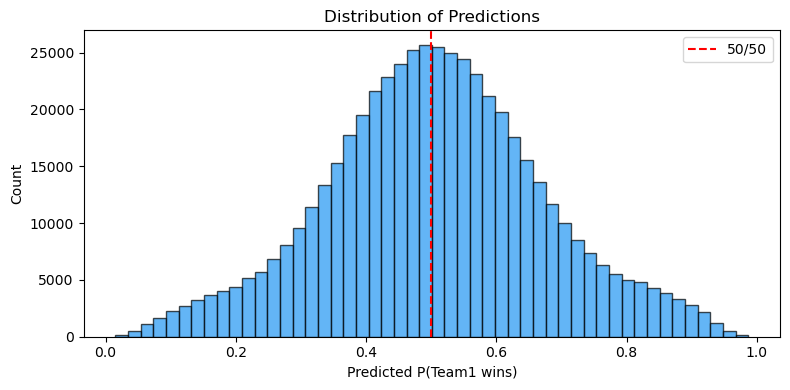

In [ ]:

# ── Quick sanity check: distribution of predictions ──
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(sub['Pred'], bins=50, edgecolor='black', alpha=0.7, color='#2196F3')
ax.axvline(0.5, color='red', linestyle='--', label='50/50')
ax.set_xlabel('Predicted P(Team1 wins)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Predictions')
ax.legend()
plt.tight_layout()
plt.show()

## 6．この基準値を改善するためのアイデア


この入門版でも有効な提出物にはなりますが、改善の余地はたくさんあります。以下にいくつかの手順を示します。

**より優れた機能**
- 詳細なボックススコア：MRegularSeasonDetailedResults.csvシュート成功率、リバウンド、ターンオーバーなどに使用します。
- 対戦相手の強さ：対戦相手の強さによるEloレーティングの更新
- Massey Ordinals：このMMasseyOrdinals.csvファイルには、100以上のシステム（Sagarin、Pomeroy、RPIなど）のランキングが含まれています。
- 直近の試合の重み付け：シーズン終盤の試合に重み付けを増やす
- カンファレンスの強さ：カンファレンスレベルのEloレーティングを計算するか、カンファレンストーナメントの結果を使用する

**より良いモデル**
- より多くの機能を備えたグラデーションブースティング（XGBoost、LightGBM）
- 複数のモデル（Eloレーティングベース、シードベース、統計ベース）をアンサンブルする
- 複雑な特徴間の相互作用を学習するためのニューラルネットワーク

**エージェントをもっと増やす**
- ParallelAgent男性と女性の特徴を同時に計算する
- LoopAgentハイパーパラメータの調整（Kファクター、ホームコートアドバンテージ）を繰り返す
- 分析エージェント：データを探索し、特徴量を提案するエージェントを追加します。
- 検証エージェント：過去のトーナメント結果と予測を照合するエージェント